In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [18]:
# Load Dataset
data = pd.read_csv("housing.csv",sep=r'\s+', header=None)


In [19]:
# Display first 5 rows
print(data.head())

        0     1     2   3      4      5     6       7   8      9     10  \
0  0.00632  18.0  2.31   0  0.538  6.575  65.2  4.0900   1  296.0  15.3   
1  0.02731   0.0  7.07   0  0.469  6.421  78.9  4.9671   2  242.0  17.8   
2  0.02729   0.0  7.07   0  0.469  7.185  61.1  4.9671   2  242.0  17.8   
3  0.03237   0.0  2.18   0  0.458  6.998  45.8  6.0622   3  222.0  18.7   
4  0.06905   0.0  2.18   0  0.458  7.147  54.2  6.0622   3  222.0  18.7   

       11    12    13  
0  396.90  4.98  24.0  
1  396.90  9.14  21.6  
2  392.83  4.03  34.7  
3  394.63  2.94  33.4  
4  396.90  5.33  36.2  


In [4]:
# Separate Features and Target
X = data.iloc[:, :-1]

# Last column contains House Price
y = data.iloc[:, -1]

In [5]:
# Normalize Features
scaler = StandardScaler()

X = scaler.fit_transform(X)


In [6]:
# Split Dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [7]:
# Display Dataset Shape
print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (404, 13)
Testing Data Shape: (102, 13)


In [8]:
# Build Deep Neural Network Model
model = Sequential([Dense(64, activation='relu', input_shape=(X_train.shape[1],)),      # First Hidden Layer
    Dense(32, activation='relu'),          # Second Hidden Layer
    Dense(1)])                             # Output Layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [10]:
# Train Model
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 583.6738 - mae: 22.1961 - val_loss: 504.0920 - val_mae: 20.8317
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 539.2515 - mae: 21.1738 - val_loss: 461.6104 - val_mae: 19.7896
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 490.2956 - mae: 19.9830 - val_loss: 411.4413 - val_mae: 18.5052
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 429.6620 - mae: 18.4853 - val_loss: 350.7703 - val_mae: 16.8448
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 359.0603 - mae: 16.5707 - val_loss: 281.2819 - val_mae: 14.8050
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 280.7253 - mae: 14.2650 - val_loss: 208.1110 - val_mae: 12.3820
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 203.3159 - mae: 11.6341 - val_loss: 141.9627 - val_mae: 9.6733
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 142.8820 - mae: 9.4246 - val_loss: 95.8926 - val_mae: 7.4439
Epoch 9/100
11/11 

In [11]:
# Evaluate Model
loss, mae = model.evaluate( X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.2422 - mae: 2.3062


In [12]:
# Display Error
print("\nMean Absolute Error:", mae)


Mean Absolute Error: 2.3062267303466797


In [13]:
# Predict House Prices
predictions = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [14]:
# Display Prediction
print("\nPredicted Price:", predictions[0][0])

print("Actual Price:", y_test.iloc[0])


Predicted Price: 27.698938
Actual Price: 23.6


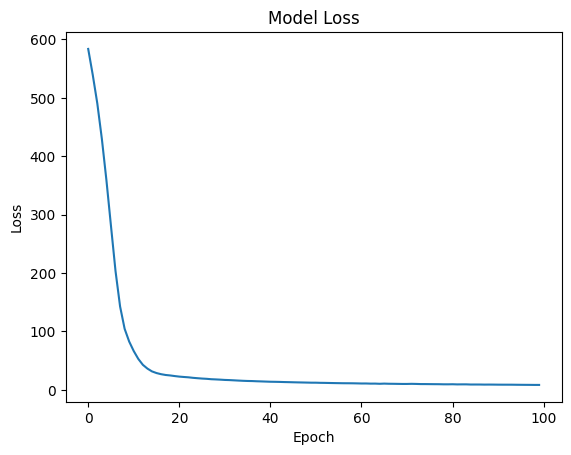

In [15]:
# Plot Training Loss Graph
plt.plot(history.history['loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()